# Visualizing result consistency during iterative code improvement

Sand-Bob gives the opportunity to inspect results of iterative code-improvement steps. After generating and executing code, the execution result is stored. Afterwards, Sand-Bob improves the code, executes it again and also these results are stored. By running the entire process multiple times, we can get an idea about how consistend results are.

**Note:** Consistent results are necessary but not sufficient condition for functional correctness. If 10 executions lead to 10 different results, one can conclude that at least 9 of the result must be wrong. But if 10 executions lead to equal results, this does not necessarily mean that those are correct.

In [1]:
from sand_bob import generate_code, config_kiara, config_scadsai_llm

#config_kiara()
config_scadsai_llm()

First, we demonstrate consistency between results and also over iterative code improvement using a code-generation prompt where the goal of the data analysis is quite precisely defined.

In [2]:
results = generate_code("""
I would like to segment the bright blobs in input_data/image.tif and count them.
For segmentation, use otsu-thresholding, connected component labeling and remove the objects sitting on the image border.
The final result should be a number.
""", 
              input_host_path="input_data",
              dependencies=["numpy", "scikit-image", "tifffile", "pandas", "matplotlib"],
              n_parallel=3,
              n_iterative=3,
              n_codefix_attempts=2,
              n_feedback_iterations=1,
              final_touch=False,
                       )


We can visualize a summary of the final results:

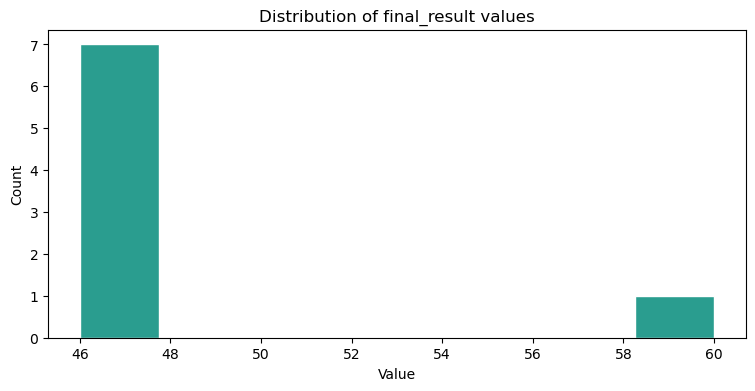

In [3]:
results.display_result_summary()

And we can also visualize how these results changed from one code-improvement iteration to another. The final results are shown on the right:

In [4]:
results.display_result_history()

Note that in the example above, the iterations end earlier compared to the example below.

## Imprecise prompting
Second, we execute a prompt which is more vague and the goal is less clear.

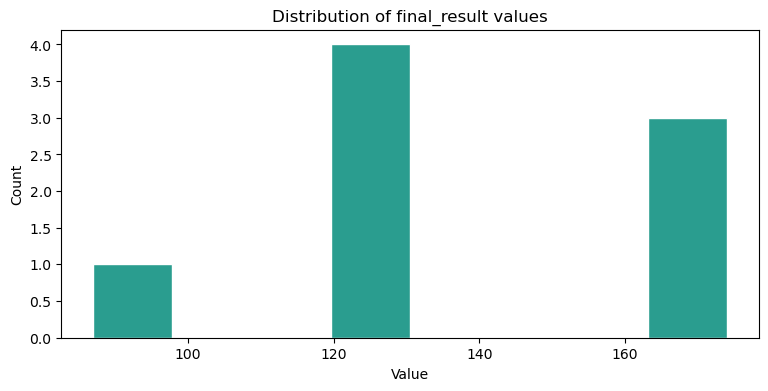

In [5]:
results = generate_code("""
I would like to segment the bright blobs in input_data/image.tif and count them.
""", 
              input_host_path="input_data",
              dependencies=["numpy", "scikit-image", "tifffile", "pandas", "matplotlib"],
              n_parallel=3,
              n_iterative=3,
              n_codefix_attempts=2,
              n_feedback_iterations=1,
              final_touch=False,
            )

results.display_result_summary()
results.display_result_history()